# Single-cell in-silico Hi-C plotting

This notebook demonstrates plotting and analysis for single-structure in-silico Hi-C simulations.

## Purpose

- Load single-structure ligation-analysis outputs, aggregated over 5000 realizations on the same structure
- Compare single-cell in-silico Hi-C maps with the corresponding contact/distance maps
- Plot single-sample aggregated ligation probabilites and contact probabilities
- Illustrate how single-structure simulations differ from ensemble-averaged results

## Notes

- This notebook is representative and supports selected single-cell / single-structure analyses.
- Input files are expected in `../../data/processed/single_cell/ligation_statistics/` and `../../data/processed/contact_probabilities/single_cell/`.

**Note:** The `.npz` datasets required for this notebook are not included in this repository and are available on Zenodo: https://doi.org/10.5281/zenodo.19682913

In [ ]:
# 1 structures from 1 files: structure 690 from file 1.
# 5000 simulation per structure
# Threshold contact distance r_c=15nm

In [3]:
import hoomd, hoomd.md
import mdtraj as md
import mbuild as mb
import numpy  as np
import random
import os.path
import sys
import scipy as sp
from scipy.spatial import distance
import gsd
import gsd.fl, gsd.hoomd
import warnings
warnings.filterwarnings('ignore')

import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.sparse as sparse
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
#Import ligation probability, distance map and contact map of single cell in-silico Hi-C

output_dir = "../../data/processed/single_cell/ligation_statistics/"
g=np.load(output_dir+'combined_ft_lig_data_C_7_region_95.4-96.5_nkeep_5000_rc_1.5.npz', allow_pickle=True)

In [5]:
print(g.files)

['ligation_prob_global', 'ligation_map_global', 'ligation_events', 'self_ligation_events', 'nf', 'p_ligation1', 'p_ligation2', 'ligation_distances', 'init_contact_map_final', 'init_contact_map_final_2', 'rthresh', 'initial_distance_final', 'Pcycle_L_final', 'Ncycle_L_final', 'Nlong_L_final', 'cycle_bins', 'ligation_map_global_new', 'ligation_prob_global_new', 'p_ligation_new', 'tot_nlig_new', 'cum_history_mat']


In [6]:
lpg=g['ligation_prob_global']
lmg=g['ligation_map_global']
lev=g['ligation_events']
sle=g['self_ligation_events']
nf=g['nf']
pl1=g['p_ligation1']
pl2=g['p_ligation2']
ld=g['ligation_distances']

Nlong_L=g['Nlong_L_final']
Pcycle_L=g['Pcycle_L_final']
Ncycle_L=g['Ncycle_L_final']
cycle_bins=g['cycle_bins']
icm=g['init_contact_map_final']
icm2=g['init_contact_map_final_2']
rthresh=g['rthresh']
idm=g['initial_distance_final']
nf=g['nf']

lmgn=g['ligation_map_global_new']
lpgn=g['ligation_prob_global_new']
pln=g['p_ligation_new']
tnln=g['tot_nlig_new']
hist=g['cum_history_mat']

In [10]:
lig_probs = np.array([1.0,0.1,0.01,0.001])
Nprobs = len(lig_probs)
p_legend = [r'$p = $'+str(1.0)+r' $p_o$',r'$p = $'+str(0.1)+r' $p_o$',r'$p = $'+str(0.01)+r' $p_o$',r'$p = $'+str(0.001)+r' $p_o$']


In [ ]:
#Contact probability, distance map and contact map of single sample
cprob_dir = "../../data/processed/contact_probabilities/single-cell/"
g_scHiC = np.load(cprob_dir+'file_1_str_690/distance_contact_map_C_7_region_95.4-96.5.npz', allow_pickle=True)

dma_scHiC=g_scHiC['distance_map_average']
cma_scHiC=g_scHiC['contact_map_average']
cpa_scHiC=g_scHiC['contact_prob_average']
nf_scHiC=g_scHiC['nf']

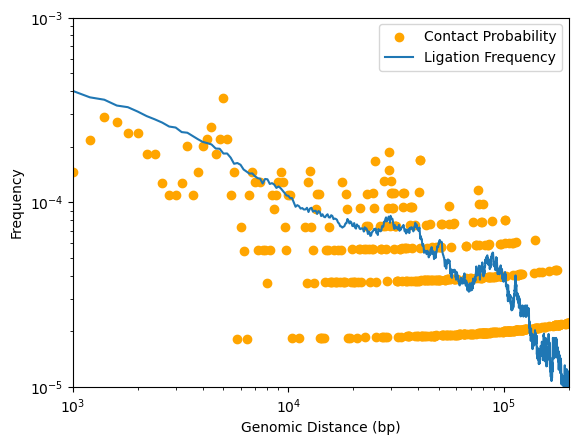

In [ ]:
# Plot aggregate ligation probability of single-cell experiment, over 5000 simulations on the same structure
# Plot underlying contac probability of the same single-cell structure for comparison

# Generate filtered data - Remove zeroes from contact probability
lower = 0

u = []
v = []
for xx, yy in zip(gen_dist, cpa_scHiC):
    if yy > lower:
        u.append(xx)
        v.append(yy)
        
#print(u)
#print(v)

#plt.plot(gen_dist*200, cpa_scHiC/10)
plt.scatter(gen_dist*200, cpa_scHiC/10, marker=r'o', color='orange')
plt.plot(gen_dist*200, lpg[1])
#plt.scatter(u*200, v/10)

scHic_legend = ['Contact Probability', 'Ligation Frequency']
plt.legend(scHic_legend)
plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Frequency')
#plt.yscale("log")
#plt.xscale("log")
plt.ylim([1e-5,1e-3])
plt.xlim([1000,2e5])

plt.yscale("log")
plt.xscale("log")


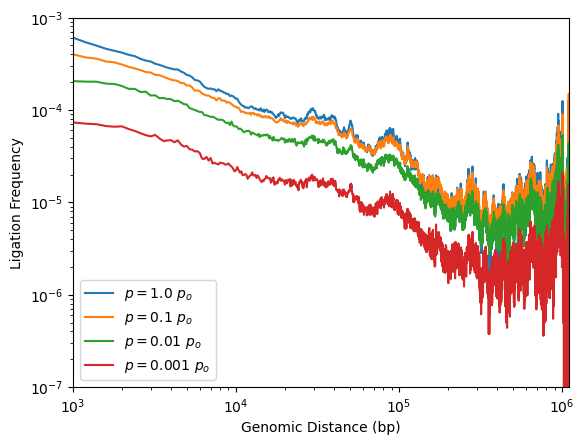

In [ ]:
#Ligation frequencies as a function of genomic distance for different ligation efficiencies
#These curves result from aggregating 5000 single-cell experiments over the same structure

for pi in range(Nprobs):
    plt.plot(gen_dist*200,lpg[pi])
#plt.plot([1e1,1e2],[1e-4,1e-5])


plt.legend(p_legend)
plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Frequency')
plt.yscale("log")
plt.xscale("log")
plt.ylim([1e-7,1e-3])
plt.xlim([1000,5500*200])
plt.show()

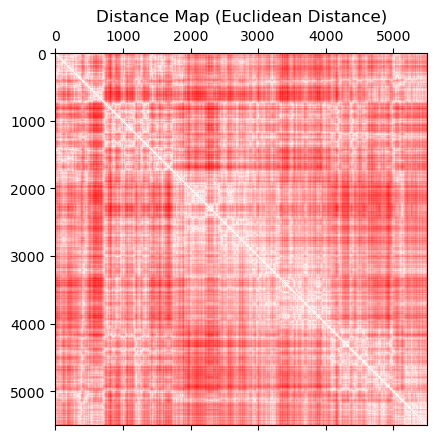

In [ ]:
#Distance map of the single-cell structure

distance_map = idm[:,:] #+ np.transpose(idm[:,:]) - np.diag(np.diag(idm[:,:]))
plt.matshow(idm[:,:], cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]) )#, vmin=0, vmax=1e-4)
plt.title('Distance Map (Euclidean Distance)')
plt.show()
#np.savetxt('dist_map.csv', distance_map, delimiter=" ") #,fmt="%d")

In [15]:
rthresh

array([15.  , 11.25,  7.5 ,  3.75,  1.5 ])

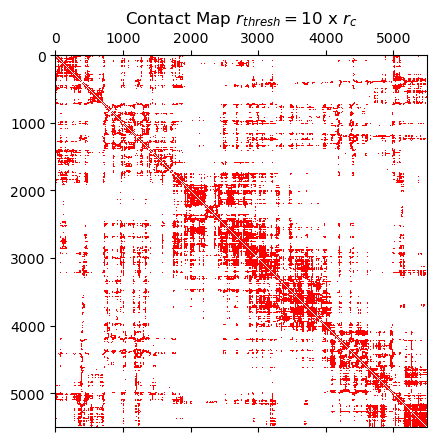

In [ ]:
#Sparse single-cell contact map with a contact threshold distance 10xr_c

symm = icm2[0] - np.diag(np.diag(icm2[0])) #+ np.transpose(icm2[1]) - 2*np.diag(np.diag(icm2[1]))
plt.matshow(symm, cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=1e-4)
plt.title('Contact Map $r_{thresh} = $'+str(10)+' x $r_c$')
plt.show()
#np.savetxt('contactmap_rthresh_10xrc.csv', symm, delimiter=" ")

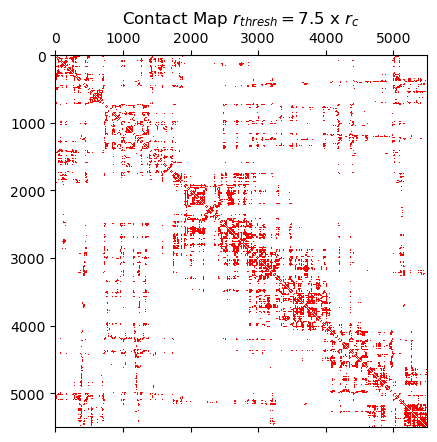

In [ ]:
#Sparse single-cell contact map with a contact threshold distance 7.5xr_c

symm = icm2[1] - np.diag(np.diag(icm2[1])) #+ np.transpose(icm2[1]) - 2*np.diag(np.diag(icm2[1]))
plt.matshow(symm, cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=1e-4)
plt.title('Contact Map $r_{thresh} = $'+str(7.5)+' x $r_c$')
plt.show()
#np.savetxt('contactmap_rthresh_7.5xrc.csv', symm, delimiter=" ")

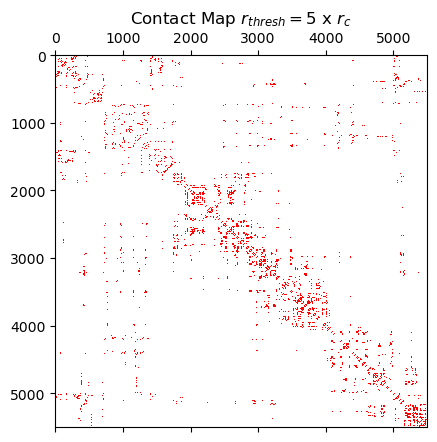

In [ ]:
#Sparse single-cell contact map with a contact threshold distance 5xr_c

symm = icm2[2] - np.diag(np.diag(icm2[2])) #+ np.transpose(icm2[1]) - 2*np.diag(np.diag(icm2[1]))
plt.matshow(symm, cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=1e-4)
plt.title('Contact Map $r_{thresh} = $'+str(5)+' x $r_c$')
plt.show()
#np.savetxt('contactmap_rthresh_5xrc.csv', symm, delimiter=" ")

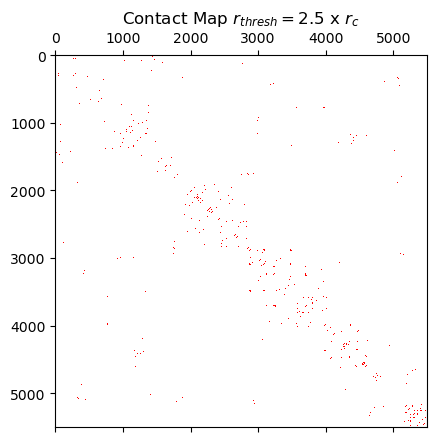

In [ ]:
#Sparse single-cell contact map with a contact threshold distance 2.5xr_c

symm = icm2[3] - np.diag(np.diag(icm2[3])) #+ np.transpose(icm2[1]) - 2*np.diag(np.diag(icm2[1]))
plt.matshow(symm, cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=1e-4)
plt.title('Contact Map $r_{thresh} = $'+str(2.5)+' x $r_c$')
plt.show()
#np.savetxt('contactmap_rthresh_2.5xrc.csv', symm, delimiter=" ")

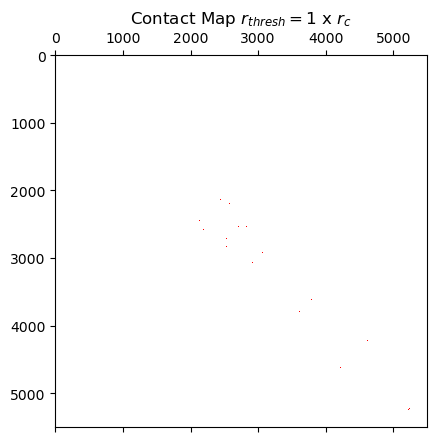

In [ ]:
#Sparse single-cell contact map with a contact threshold distance 1xr_c

symm = icm2[4] - np.diag(np.diag(icm2[4])) #+ np.transpose(icm2[1]) - 2*np.diag(np.diag(icm2[1]))
plt.matshow(symm, cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=1e-4)
plt.title('Contact Map $r_{thresh} = $'+str(1)+' x $r_c$')
plt.show()
#np.savetxt('contactmap_rthresh_1xrc.csv', symm, delimiter=" ")

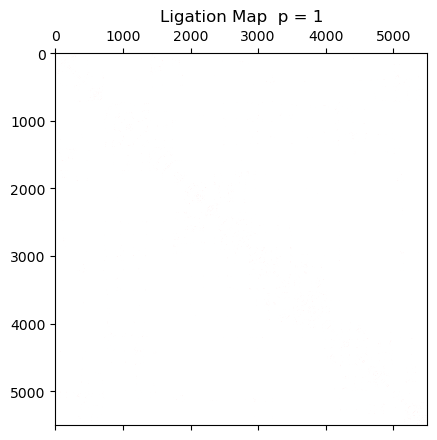

In [ ]:
#Ligation map with with a ligation efficiency p/p_o=1
#The map result from aggregating 5000 single-cell experiments over the same structure

symm = lmg[0,:,:] + np.transpose(lmg[0,:,:]) - np.diag(np.diag(lmg[0,:,:]))
plt.matshow(symm, cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]))#, vmin=0, vmax=1e-4)
plt.title('Ligation Map  p = '+str(1))
plt.show()
#np.savetxt('ligmap_p_1e-0.csv', symm, delimiter=" ") #,fmt="%d")

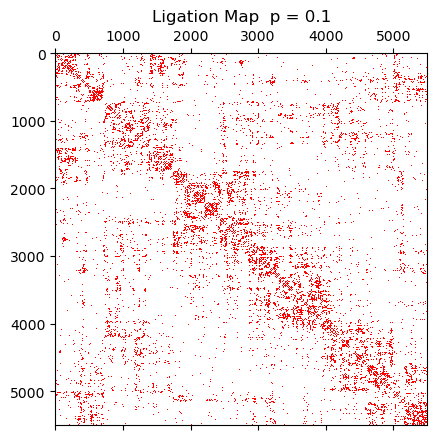

In [ ]:
#Ligation map with with a ligation efficiency p/p_o=0.1
#The map result from aggregating 5000 single-cell experiments over the same structure

symm = lmg[1,:,:] + np.transpose(lmg[1,:,:]) - np.diag(np.diag(lmg[1,:,:]))
plt.matshow(symm, cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=1e-4)
plt.title('Ligation Map  p = '+str(0.1))
plt.show()
#np.savetxt('ligmap_p_1e-1.csv', symm, delimiter=" ") #,fmt="%d")

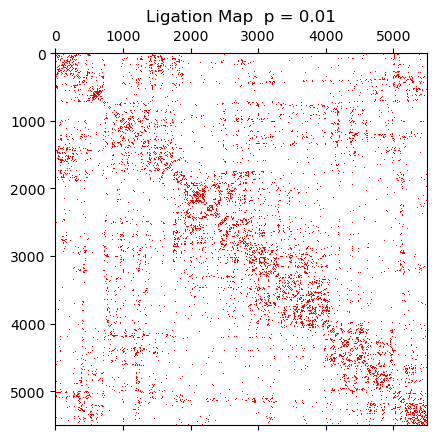

In [ ]:
#Ligation map with with a ligation efficiency p/p_o=0.01
#The map result from aggregating 5000 single-cell experiments over the same structure

symm = lmg[2,:,:] + np.transpose(lmg[2,:,:]) - np.diag(np.diag(lmg[2,:,:]))
plt.matshow(symm, cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=1e-4)
plt.title('Ligation Map  p = '+str(0.01))
plt.show()
#np.savetxt('ligmap_p_1e-2.csv', symm, delimiter=" ") #,fmt="%d")

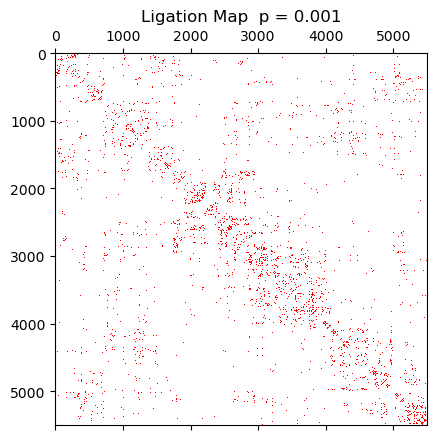

In [ ]:
#Ligation map with with a ligation efficiency p/p_o=0.001
#The map result from aggregating 5000 single-cell experiments over the same structure

symm = lmg[3,:,:] + np.transpose(lmg[3,:,:]) - np.diag(np.diag(lmg[3,:,:]))
plt.matshow(symm, cmap=LinearSegmentedColormap.from_list("bright_red",[(1,1,1),(1,0,0)]), vmin=0, vmax=1e-4)
plt.title('Ligation Map  p = '+str(0.001))
plt.show()
#np.savetxt('ligmap_p_1e-3.csv', symm, delimiter=" ") #,fmt="%d")

In [26]:
print(np.sum(lmg[0,:,:]),np.max(lmg[0,:,:]),np.min(lmg[0,:,:]))
print(lmg[0,5,:])

453.5384000000003 0.082 0.0
[0. 0. 0. ... 0. 0. 0.]


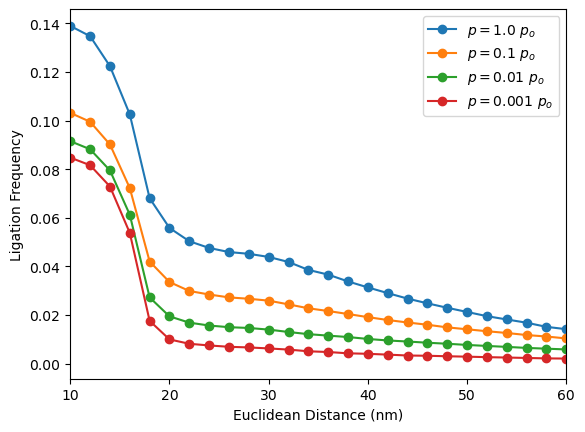

In [ ]:
#Ligation probability as a function of Euclidean distance for single-cell numerical experiment
#The curves result from aggregating 5000 single-cell experiments over the same structure

for pi in range(Nprobs):
    plt.plot(10*ld[0:49],pl1[pi], '-o')
#plt.plot(10*ld[0:49],pl1[5], '-o')
plt.legend(p_legend)
plt.xlim([10,60])
#plt.ylim([0,0.02])
#plt.yscale("log")
plt.xlabel('Euclidean Distance (nm)')
plt.ylabel('Ligation Frequency')
plt.show()